In [1]:
from scipy.stats import norm
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn.datasets

from sklearn.model_selection import train_test_split

from sklearn import metrics

import aed_funcoes as aed

In [4]:
df_results = pd.read_csv("feedbacks/resultados_congresso.csv")
df_results.head()

,idade_predita,idade_real,erro_absoluto,limite_inferior,limite_superior,dentro_do_intervalo
0,29.47,26.0,3.47,13.03,46.12,1
1,36.30,55.0,18.70,18.42,54.35,0
2,29.01,55.0,25.99,10.71,47.64,0
3,19.04,25.0,5.96,10.89,27.75,1


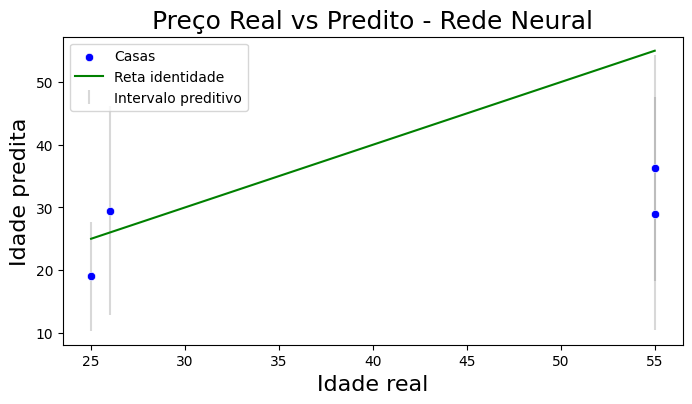

In [7]:
y_true = df_results["idade_real"]
y_pred = df_results["idade_predita"]
y_pred_upper = df_results["limite_superior"]

margem_erro = y_pred_upper - y_pred

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,4))

sns.scatterplot(x = y_true, y = y_pred, ax = ax, color = 'blue', zorder = 2, label = "Casas")

ax.errorbar(
    x = y_true, 
    y = y_pred, 
    yerr = margem_erro,
    fmt = 'none',       # 'none' para não desenhar pontos ou linhas entre eles, apenas as barras
    ecolor = 'gray',    # cor das barras
    alpha = 0.3,
    zorder = 1,
    label = r"Intervalo preditivo"
)

limite_min = np.min(y_true)
limite_max = np.max(y_true)
ax.plot([limite_min, limite_max], [limite_min, limite_max], color="green", zorder=3, label = "Reta identidade")

ax.set_xlabel("Idade real", fontsize = 16)
ax.set_ylabel("Idade predita", fontsize = 16)
ax.set_title("Preço Real vs Predito - Rede Neural", fontsize = 18)

ax.legend(loc = "upper left")

plt.show()